In [71]:
#importing the Libraies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
# Reading the Dataset
dataset = pd.read_csv('50_Startups.csv')

In [75]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [77]:
datasets=pd.get_dummies(dataset,drop_first=True)

In [79]:
datasets

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False
5,131876.90,99814.71,362861.36,156991.12,False,True
6,134615.46,147198.87,127716.82,156122.51,False,False
7,130298.13,145530.06,323876.68,155752.60,True,False
8,120542.52,148718.95,311613.29,152211.77,False,True
9,123334.88,108679.17,304981.62,149759.96,False,False


In [81]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [83]:
indep=datasets[['R&D Spend','Administration', 'Marketing Spend','State_Florida', 'State_New York']]
dep=datasets[['Profit']]

In [85]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
param_grid={'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],'max_features': [None,'sqrt','log2'],'splitter':['best','random']}
grid=GridSearchCV(DecisionTreeRegressor(),param_grid,refit=True, verbose=3,n_jobs=-1)
grid.fit(indep,dep)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse'],
                         'max_features': [None, 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             verbose=3)

In [86]:
grid.best_score_

-4.311354817887863

In [87]:
re=grid.cv_results_
re

{'mean_fit_time': array([0.0047256 , 0.00539174, 0.00490279, 0.00310736, 0.00350657,
        0.0035758 , 0.00345163, 0.0044426 , 0.00358028, 0.00339894,
        0.00458837, 0.00371437, 0.00330272, 0.00332055, 0.00402522,
        0.00328584, 0.00336876, 0.00393963]),
 'std_fit_time': array([0.00113345, 0.00164626, 0.00166609, 0.00070153, 0.00046769,
        0.00105737, 0.00120103, 0.00151785, 0.00118532, 0.00048927,
        0.00194775, 0.00026111, 0.00074931, 0.00043252, 0.00106225,
        0.00040741, 0.00053423, 0.0002347 ]),
 'mean_score_time': array([0.00408545, 0.00312147, 0.00272355, 0.00408707, 0.00291967,
        0.00312996, 0.00411134, 0.00262585, 0.00328135, 0.0031496 ,
        0.00327711, 0.00220027, 0.00242152, 0.00260973, 0.00248976,
        0.00285869, 0.00308905, 0.00263   ]),
 'std_score_time': array([1.99912337e-03, 1.46308715e-03, 1.28131241e-03, 1.66453414e-03,
        8.04371894e-04, 9.65187257e-04, 2.44707128e-03, 8.01470849e-04,
        1.28521741e-03, 7.52053380e-

In [88]:
table=pd.DataFrame.from_dict(re)

In [89]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004726,0.001133,0.004085,0.001999,squared_error,None,best,"{'criterion': 'squared_error', 'max_features':...",-6.462478,-2.646362,-13.516897,-2.400382,-1.667017,-5.338627,4.416094,3
1,0.005392,0.001646,0.003121,0.001463,squared_error,None,random,"{'criterion': 'squared_error', 'max_features':...",-5.213418,-5.843474,-5.660220,-2.347151,-2.492512,-4.311355,1.558643,1
2,0.004903,0.001666,0.002724,0.001281,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",-12.851744,-36.330834,-18.110587,-36.788566,-3.411594,-21.498665,13.169395,18
3,0.003107,0.000702,0.004087,0.001665,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",-6.227437,-22.459208,-23.979118,-2.253155,-4.970432,-11.977870,9.280411,8
4,0.003507,0.000468,0.002920,0.000804,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",-7.660699,-26.672222,-14.623031,-24.038645,-2.785473,-15.156014,9.176255,12
5,0.003576,0.001057,0.003130,0.000965,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",-8.622512,-6.395961,-9.041083,-3.503350,-2.886103,-6.089802,2.536606,6
6,0.003452,0.001201,0.004111,0.002447,absolute_error,None,best,"{'criterion': 'absolute_error', 'max_features'...",-4.860764,-3.810427,-13.444010,-2.927967,-2.673719,-5.543377,4.024037,4
7,0.004443,0.001518,0.002626,0.000801,absolute_error,None,random,"{'criterion': 'absolute_error', 'max_features'...",-4.723019,-9.124780,-7.390638,-2.123843,-2.563591,-5.185174,2.714502,2
8,0.003580,0.001185,0.003281,0.001285,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",-9.297784,-12.617468,-23.007035,-9.815917,-6.320607,-12.211762,5.755685,9
9,0.003399,0.000489,0.003150,0.000075,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",-15.919915,-4.543435,-27.560650,-42.977691,-3.436103,-18.887559,14.892047,17


# grid.best_score_ and the mean_test_score (rank_test_score == 1) will match 
# only if GridSearchCV, cv_results_, and the table are run sequentially in order;
# otherwise, running cells out of order may show different values


In [91]:
table.loc[table['rank_test_score'] == 1, 'mean_test_score']


1   -4.311355
Name: mean_test_score, dtype: float64

In [92]:
grid.best_score_


-4.311354817887863

In [100]:

best_tree=grid.best_estimator_

# otherwise, running cells out of order may show different values,below best score is different because we are not running sequential order


In [103]:
print("the R_score value for best Paramater is:",grid.best_params_,"\n and R Score is ", grid.best_score_)

the R_score value for best Paramater is: {'criterion': 'squared_error', 'max_features': None, 'splitter': 'random'} 
 and R Score is  -4.311354817887863


In [105]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004726,0.001133,0.004085,0.001999,squared_error,None,best,"{'criterion': 'squared_error', 'max_features':...",-6.462478,-2.646362,-13.516897,-2.400382,-1.667017,-5.338627,4.416094,3
1,0.005392,0.001646,0.003121,0.001463,squared_error,None,random,"{'criterion': 'squared_error', 'max_features':...",-5.213418,-5.843474,-5.660220,-2.347151,-2.492512,-4.311355,1.558643,1
2,0.004903,0.001666,0.002724,0.001281,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",-12.851744,-36.330834,-18.110587,-36.788566,-3.411594,-21.498665,13.169395,18
3,0.003107,0.000702,0.004087,0.001665,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",-6.227437,-22.459208,-23.979118,-2.253155,-4.970432,-11.977870,9.280411,8
4,0.003507,0.000468,0.002920,0.000804,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",-7.660699,-26.672222,-14.623031,-24.038645,-2.785473,-15.156014,9.176255,12
5,0.003576,0.001057,0.003130,0.000965,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",-8.622512,-6.395961,-9.041083,-3.503350,-2.886103,-6.089802,2.536606,6
6,0.003452,0.001201,0.004111,0.002447,absolute_error,None,best,"{'criterion': 'absolute_error', 'max_features'...",-4.860764,-3.810427,-13.444010,-2.927967,-2.673719,-5.543377,4.024037,4
7,0.004443,0.001518,0.002626,0.000801,absolute_error,None,random,"{'criterion': 'absolute_error', 'max_features'...",-4.723019,-9.124780,-7.390638,-2.123843,-2.563591,-5.185174,2.714502,2
8,0.003580,0.001185,0.003281,0.001285,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",-9.297784,-12.617468,-23.007035,-9.815917,-6.320607,-12.211762,5.755685,9
9,0.003399,0.000489,0.003150,0.000075,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",-15.919915,-4.543435,-27.560650,-42.977691,-3.436103,-18.887559,14.892047,17


In [107]:
imp=best_tree.feature_importances_

In [109]:
imp

array([0.96109607, 0.00506472, 0.02467854, 0.00304463, 0.00611604])

In [111]:
imp=best_tree.max_features_

In [113]:
imp

5

In [115]:
imp=best_tree.tree_

In [117]:
imp

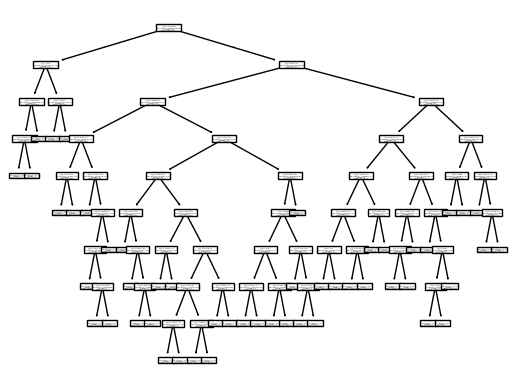

In [119]:
from sklearn import tree
best_tree=grid.best_estimator_
tree.plot_tree(best_tree)
plt.show()

In [121]:
rd_input=float(input("R&D:"))
admin_input=float(input("Admin"))
mark_input=float(input("Marketing "))
fol_input=int(input("State_flo 0 or 1:"))
new_input=int(input("State_new 0 or 1:"))

R&D: 162597.7
Admin 151377.59
Marketing  443898.53
State_flo 0 or 1: 0
State_new 0 or 1: 0


In [123]:
result=grid.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])

C:\Users\alkar\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [125]:
result

array([191792.06])